# CS133 Project — P4: Machine Learning

**Team Name**: Group 16  
**Team Members**: Hrishikesh Giri, Srihan Cheemangunta, Yeqing Xu



## Goal

Using Fantasy Premier League (FPL) match-by-match player data, we train regression models to **predict a player's total points in the next gameweek** based on their recent performance history and contextual factors.

We address the following project questions:
- **Q1**: How well can we predict a player's next-game performance using historical statistics?
- **Q2**: How do contextual factors (home/away, opponent strength, value) affect player output?
- **Q3**: What combination of players is expected to maximize team performance under budget constraints?
- **Q4**: Which statistics are the strongest early indicators of a breakout player?
- **Q5**: If a key player is unavailable, can we recommend the best replacement?



## Outline

1. Setup & Data Loading
2. Feature Engineering (Lag / Rolling Features)
3. EDA for ML (Correlations & Distributions)

Modeling pipeline — we run sections 4–7 twice, once per variant, then compare:
- **Model A — Cross-Season Variant** (4A → 7A): train on 2024-25, test on 2025-26
- **Model B — Single-Season Variant** (4B → 7B): train on 2025-26 GW1–21, test on GW22–29
- Model A vs Model B comparison

8. Application: Q1 Prediction / Q4 Breakout Indicators / Q5 Replacement Recommendation

(Summary & Limitations at the end.)
## Three ML Models
- LinearRegression
- DecisionTreeRegressor
- RandomForestRegressor


## 1. Setup & Data Loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
print('Libraries loaded.')

Libraries loaded.


In [ ]:
# Load FPL gameweek data for two seasons
seasons = ['2024-25', '2025-26']
all_dfs = []

for season in seasons:
    url = f'https://raw.githubusercontent.com/vaastav/Fantasy-Premier-League/master/data/{season}/gws/merged_gw.csv'
    try:
        temp = pd.read_csv(url, encoding='utf-8')
    except UnicodeDecodeError:
        temp = pd.read_csv(url, encoding='latin-1')
    temp['season'] = season
    all_dfs.append(temp)
    print(f'{season}: {temp.shape[0]} rows loaded')

raw = pd.concat(all_dfs, ignore_index=True)
print(f'\nCombined shape: {raw.shape}')
raw.head(3)

2024-25: 27605 rows loaded
2025-26: 22353 rows loaded

Combined shape: (49958, 54)


,name,position,team,xP,assists,bonus,bps,clean_sheets,creativity,element,...,transfers_out,value,was_home,yellow_cards,GW,season,clearances_blocks_interceptions,defensive_contribution,recoveries,tackles
0,Alex Scott,MID,Bournemouth,1.6,0,0,11,0,12.8,77,...,0,50,False,0,1,2024-25,NaN,NaN,NaN,NaN
1,Carlos Miguel dos Santos Pereira,GK,Nott'm Forest,2.2,0,0,0,0,0.0,427,...,0,45,True,0,1,2024-25,NaN,NaN,NaN,NaN
2,Tomiyasu Takehiro,DEF,Arsenal,0.0,0,0,0,0,0.0,22,...,0,50,True,0,1,2024-25,NaN,NaN,NaN,NaN


In [ ]:
# Load team strength data to encode opponent difficulty
team_dfs = []
for season in seasons:
    url = f'https://raw.githubusercontent.com/vaastav/Fantasy-Premier-League/master/data/{season}/teams.csv'
    try:
        tdf = pd.read_csv(url)[['id', 'name', 'strength']]
        tdf['season'] = season
        team_dfs.append(tdf)
    except Exception as e:
        print(f'Could not load teams for {season}: {e}')

teams = pd.concat(team_dfs, ignore_index=True)
print('Team data shape:', teams.shape)
teams.head(3)

Team data shape: (40, 4)


,id,name,strength,season
0,1,Arsenal,5,2024-25
1,2,Aston Villa,3,2024-25
2,3,Bournemouth,3,2024-25


In [ ]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49958 entries, 0 to 49957
Data columns (total 54 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   name                             49958 non-null  object 
 1   position                         49958 non-null  object 
 2   team                             49958 non-null  object 
 3   xP                               49958 non-null  float64
 4   assists                          49958 non-null  int64  
 5   bonus                            49958 non-null  int64  
 6   bps                              49958 non-null  int64  
 7   clean_sheets                     49958 non-null  int64  
 8   creativity                       49958 non-null  float64
 9   element                          49958 non-null  int64  
 10  expected_assists                 49958 non-null  float64
 11  expected_goal_involvements       49958 non-null  float64
 12  expected_goals    

In [ ]:
teams.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        40 non-null     int64 
 1   name      40 non-null     object
 2   strength  40 non-null     int64 
 3   season    40 non-null     object
dtypes: int64(2), object(2)
memory usage: 1.4+ KB



## 2. Feature Engineering

Since we are predicting the **next gameweek's points**, we must engineer features from **past gameweeks only** (no data leakage).

In [ ]:
# Basic cleaning
df = raw.copy()

# Filter to outfield positions; drop manager rows
valid_positions = ['GK', 'DEF', 'MID', 'FWD']
df['position'] = df['position'].str.upper().str.strip()
df = df[df['position'].isin(valid_positions)].copy()

# Sort chronologically per player within each season
df = df.sort_values(['season', 'name', 'GW']).reset_index(drop=True)

print('Rows after position filter:', len(df))
print('Positions:', df['position'].value_counts().to_dict())

Rows after position filter: 49636
Positions: {'MID': 22228, 'DEF': 16490, 'FWD': 5479, 'GK': 5439}


In [ ]:
# Merge opponent strength
# Map opponent_team id to strength score using the teams table
opp_map = teams.set_index(['season', 'id'])['strength']

def get_opp_strength(row):
    try:
        return opp_map.loc[(row['season'], row['opponent_team'])]
    except KeyError:
        return np.nan

df['opponent_strength'] = df.apply(get_opp_strength, axis=1)
print('Opponent strength NaNs:', df['opponent_strength'].isna().sum())

Opponent strength NaNs: 0


In [ ]:
# Step 1: Drop exact duplicate rows
df = df.drop_duplicates()

# Step 2: For remaining duplicates - sum points/stats, keep first for everything else
agg_dict = {}
for col in df.columns:
    if col in ['season', 'name', 'GW']:
        continue
    elif col in ['total_points', 'goals_scored', 'assists', 'bonus',
                 'saves', 'clean_sheets', 'yellow_cards', 'red_cards']:
        agg_dict[col] = 'sum'
    else:
        agg_dict[col] = 'first'

df = df.groupby(['season', 'name', 'GW'], as_index=False).agg(agg_dict)

# Verify
for season in df['season'].unique():
    dupes = df[df['season'] == season].duplicated(subset=['name', 'GW']).sum()
    print(f'{season}: {dupes} duplicates remaining')
print(f'Shape after fix: {df.shape}')

2024-25: 0 duplicates remaining
2025-26: 0 duplicates remaining
Shape after fix: (49183, 55)


In [ ]:
# Reindex per season to avoid cross-season duplicate issue
season_dfs = []
for season in df['season'].unique():
    season_df = df[df['season'] == season].copy()

    all_gws = range(1, 39)
    idx = pd.MultiIndex.from_product(
        [season_df['name'].unique(), all_gws],
        names=['name', 'GW']
    )

    season_df = (season_df.set_index(['name', 'GW'])
                           .reindex(idx)
                           .reset_index())
    season_df['season'] = season  # re-add season column
    season_dfs.append(season_df)

df = pd.concat(season_dfs, ignore_index=True)

print(f'Shape after reindex: {df.shape}')
print(f'Missing GW rows added: {df["total_points"].isna().sum()}')

Shape after reindex: (60952, 55)
Missing GW rows added: 11769


### Use Rolling Features

Each row in the FPL dataset is one player in one gameweek, and these rows are **connected through time** — each player has a chain of games (GW1 → GW2 → GW3 → ...). Using the raw columns from the dataset (like `ict_index`, `creativity`, `threat`) as features directly would be cheating, because the model would be reading the answer at the same time as making the prediction.

To avoid data leakage, we use the information from previous gameweeks. So instead of using GW10's `ict_index`, we use the **average `ict_index` from GW7, GW8, GW9**. This is a **rolling average**.

We compute rolling averages over two windows:
- **3-gameweek window** (`_roll3`): captures short-term hot/cold streaks
- **5-gameweek window** (`_roll5`): captures longer-term form trends

`shift(1)` slides the data back by one row before averaging, so the current gameweek's value is never included in its own feature calculation.

Without `shift(1)`:


| GW | points | rolling(3).mean() includes... |
| -------- | -------- | -------- |
| 10    | 8   | GW8 + GW9 + GW10 ← cheating   |



With `shift(1)`:


| GW | points | shift(1) | rolling(3).mean() includes... |
| -------- | -------- | -------- | -------- |
| 10    | 8   | GW9's value | GW7 + GW8 + GW9 ← honest   |


In [ ]:
rolling_cols = [
    'total_points', 'minutes', 'goals_scored', 'assists',
    'bonus', 'ict_index', 'creativity', 'threat', 'influence',
    'xP', 'expected_goals', 'expected_assists',
    'clean_sheets', 'saves',
    'defensive_contribution'
]

for col in rolling_cols:
    if col in df.columns:
        df[f'_{col}_played'] = df[col].where(df['minutes'] > 0)

for col in rolling_cols:
    if col in df.columns:
        df[f'{col}_roll3'] = (
            df.groupby(['season', 'name'])[f'_{col}_played']
              .transform(lambda x: x.shift(1)
                                    .rolling(3, min_periods=1)
                                    .mean()
                                    .ffill())
        )
        df[f'{col}_roll5'] = (
            df.groupby(['season', 'name'])[f'_{col}_played']
              .transform(lambda x: x.shift(1)
                                    .rolling(5, min_periods=1)
                                    .mean()
                                    .ffill())
        )

df['points_lag1'] = (
    df.groupby(['season', 'name'])['_total_points_played']
      .transform(lambda x: x.shift(1).ffill())
)

df.drop(columns=[f'_{col}_played' for col in rolling_cols if col in df.columns], inplace=True)
print('Done.')

Done.


In [ ]:
print([c for c in df.columns if 'defensive' in c])

['defensive_contribution', 'defensive_contribution_roll3', 'defensive_contribution_roll5']


In [ ]:
# Define final feature set and target
# Target: total_points in THIS gameweek
# (we use prior-GW roll features to predict it)

feature_cols_num = [
    'total_points_roll3', 'total_points_roll5', 'points_lag1',
    'minutes_roll3', 'minutes_roll5',
    'ict_index_roll3', 'creativity_roll3', 'threat_roll3', 'influence_roll3',
    'xP_roll3', 'expected_goals_roll3', 'expected_assists_roll3',
    'bonus_roll3', 'goals_scored_roll3', 'assists_roll3',
    'clean_sheets_roll3', 'saves_roll3',
    'value', 'opponent_strength'
]
feature_cols_cat = ['position', 'was_home']
target_col = 'total_points'

all_feature_cols = feature_cols_num + feature_cols_cat

# Filter 1: skip the first 3 GWs per player (no rolling history yet)
# Filter 2: remove rows where the player did not play (minutes = 0)
#   - these rows are noise: the model has nothing to learn from a
#     player who sat on the bench. We keep them in df so their zero-minute
#     games are still captured in other players' rolling averages, but we
#     exclude them as prediction targets.
ml_df = (
    df[(df['GW'] > 3) & (df['minutes'] > 0)]
    [all_feature_cols + ['defensive_contribution_roll3', target_col, 'season', 'name', 'GW']]
    .dropna(subset=feature_cols_num[:3])
    .copy()
)

print('ML dataset shape:', ml_df.shape)
print(f'Removed {len(df[df["GW"] > 3]) - len(ml_df):,} non-playing rows')
print(f'\nTarget stats after filter:')
print(f'  Mean:   {ml_df[target_col].mean():.2f}')
print(f'  Median: {ml_df[target_col].median():.1f}')
print(f'  % rows with 0 pts: {(ml_df[target_col] == 0).mean()*100:.1f}%')

ML dataset shape: (18024, 26)
Removed 38,116 non-playing rows

Target stats after filter:
  Mean:   2.88
  Median: 2.0
  % rows with 0 pts: 5.3%



## 3. EDA for ML — Correlations & Target Distribution

We do a sanity check before training to see if our target is predictable, and whether our features are actually related to the target.

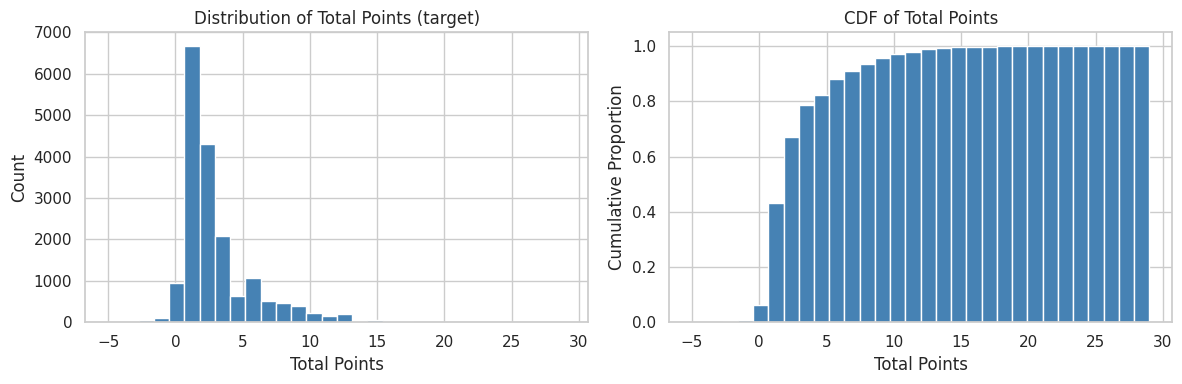

Mean: 2.88   Median: 2.0


In [ ]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(ml_df[target_col], bins=30, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Total Points')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Total Points (target)')

axes[1].hist(ml_df[target_col], bins=30, color='steelblue', edgecolor='white', cumulative=True, density=True)
axes[1].set_xlabel('Total Points')
axes[1].set_ylabel('Cumulative Proportion')
axes[1].set_title('CDF of Total Points')

plt.tight_layout()
plt.show()
print('Mean:', ml_df[target_col].mean().round(2), '  Median:', ml_df[target_col].median())

The histogram (left) displays how often each points total appears across all player-gameweeks in the dataset. The CDF (right) shows the cumulative proportion.

The mean is **2.88** and median is **2.0**, which reflects a realistic playing population. The distribution is still right-skewed, showing that most players score 1–4 points in a typical gameweek, while 10+ point hauls are rare.

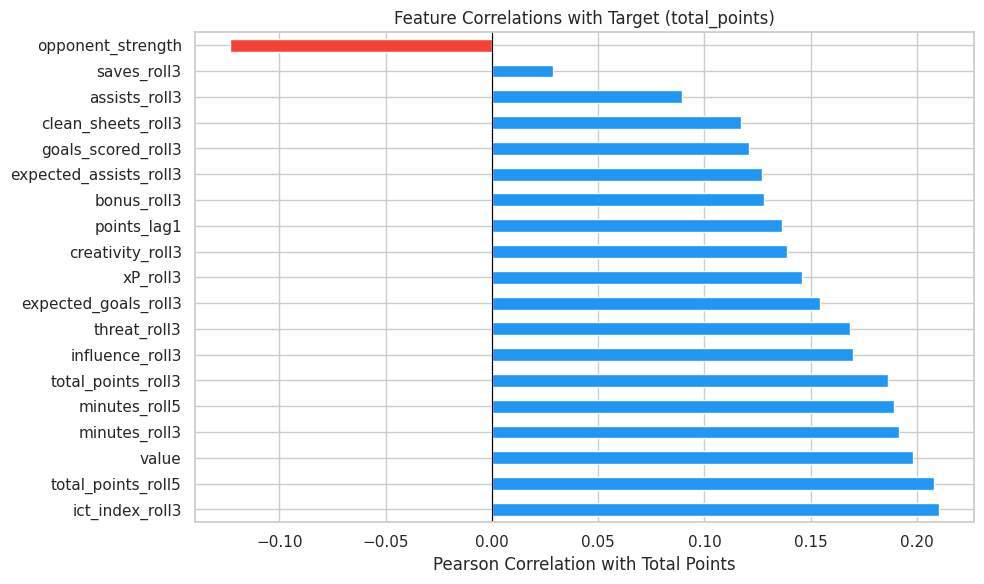

In [ ]:
# Correlation of numeric features with target
corr = ml_df[feature_cols_num + [target_col]].corr()[target_col].drop(target_col).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
colors = ['#2196F3' if v > 0 else '#F44336' for v in corr]
corr.plot(kind='barh', color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Pearson Correlation with Total Points')
plt.title('Feature Correlations with Target (total_points)')
plt.tight_layout()
plt.show()

Each bar is the Pearson correlation between one feature and `total_points`. Blue bars (positive) mean the feature and points tend to move together. A bar close to 0 means little linear relationship.

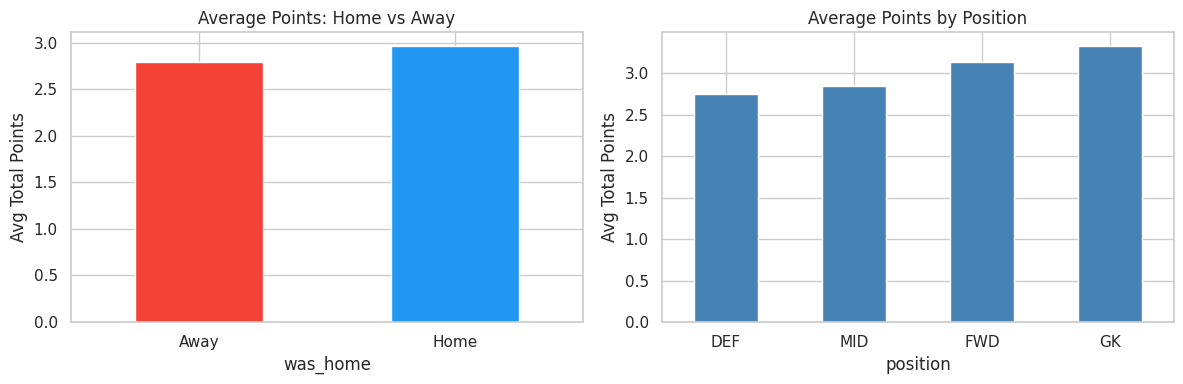

In [ ]:
# Home vs Away average points
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ml_df.groupby('was_home')[target_col].mean().plot(
    kind='bar', ax=axes[0], color=['#F44336', '#2196F3'], edgecolor='white'
)
axes[0].set_xticklabels(['Away', 'Home'], rotation=0)
axes[0].set_title('Average Points: Home vs Away')
axes[0].set_ylabel('Avg Total Points')

ml_df.groupby('position')[target_col].mean().sort_values().plot(
    kind='bar', ax=axes[1], color='steelblue', edgecolor='white'
)
axes[1].set_title('Average Points by Position')
axes[1].set_ylabel('Avg Total Points')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

Left chart: Average total points split by whether the player was at home or away. Home players score slightly more on average.

Right chart: Average total points by position. Forwards and midfielders tend to average more points than defenders and goalkeepers because the FPL scoring system rewards goals and assists heavily.

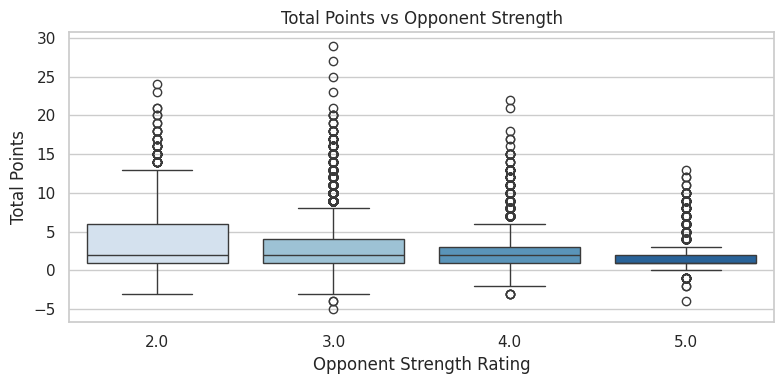

In [ ]:
# Opponent strength vs points scored
plt.figure(figsize=(8, 4))
sns.boxplot(data=ml_df, x='opponent_strength', y=target_col, palette='Blues')
plt.title('Total Points vs Opponent Strength')
plt.xlabel('Opponent Strength Rating')
plt.ylabel('Total Points')
plt.tight_layout()
plt.show()

Each box represents all player-gameweek rows facing a given opponent strength rating (2 = weakest, 5 = strongest).

## Model A — Cross-Season Variant

We start with a cross-season setup: train on the entire 2024-25 season and test on the entire 2025-26 season. This gives the most training data, but we have to drop `defensive_contribution` because that feature only exists in the 2025-26 schema.

### 4A. Prepare Data for Model A

We use a **temporal train/test split**: the entire 2024-25 season is the training set, and the entire 2025-26 season is the test set. This mirrors real-world usage — we train on past seasons and predict the current one.

In [ ]:
# Temporal split: train on 2024-25, test on 2025-26
train_df = ml_df[ml_df['season'] == '2024-25'].copy()
test_df  = ml_df[ml_df['season'] == '2025-26'].copy()

X_train = train_df[all_feature_cols]
y_train = train_df[target_col]

X_test = test_df[all_feature_cols]
y_test = test_df[target_col]

print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set:     {X_test.shape[0]} samples')

Training set: 10307 samples
Test set:     7717 samples


In [ ]:
# Build sklearn preprocessing pipeline
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, feature_cols_num),
    ('cat', categorical_transformer, feature_cols_cat)
])

print('Preprocessor built.')

Preprocessor built.



### 5A. Train & Compare Models

We evaluate three models using **5-fold cross-validation** on the training set:
- **Linear Regression** — simple baseline
- **Decision Tree Regressor** — captures non-linear patterns
- **Random Forest Regressor** — ensemble, more robust

In [ ]:
models = {
    'Linear Regression':    LinearRegression(),
    'Decision Tree':        DecisionTreeRegressor(random_state=42),
    'Random Forest':        RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

cv_results = {}

for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    scores = cross_val_score(pipe, X_train, y_train,
                             cv=5, scoring='neg_root_mean_squared_error',
                             n_jobs=-1)
    rmse_scores = -scores
    cv_results[name] = rmse_scores
    print(f'{name:25s}  CV RMSE: {rmse_scores.mean():.3f} ± {rmse_scores.std():.3f}')

Linear Regression          CV RMSE: 2.820 ± 0.170
Decision Tree              CV RMSE: 4.178 ± 0.120
Random Forest              CV RMSE: 2.910 ± 0.166



### 6A. Hyperparameter Tuning

We tune the Random Forest with `RandomizedSearchCV` (30 candidates × 5-fold CV) over `n_estimators`, `max_depth`, `min_samples_leaf`, and `max_features`.



In [ ]:
from scipy.stats import randint

param_dist = {
    'model__n_estimators':     randint(100, 500),
    'model__max_depth':        [None, 5, 10, 15, 20],
    'model__min_samples_leaf': randint(1, 20),
    'model__max_features':     ['sqrt', 'log2', 0.5]
}

rf_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42, n_jobs=-1))
])

search = RandomizedSearchCV(
    rf_pipe,
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)
search.fit(X_train, y_train)

print('\nBest Parameters:')
for k, v in search.best_params_.items():
    print(f'  {k}: {v}')
print(f'\nBest CV RMSE: {-search.best_score_:.4f}')
best_model = search.best_estimator_

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best Parameters:
  model__max_depth: 15
  model__max_features: sqrt
  model__min_samples_leaf: 14
  model__n_estimators: 341

Best CV RMSE: 2.8283



### 7A. Final Evaluation on Test Set

We evaluate the best tuned Model A on the held-out 2025-26 season data.

Test RMSE : 2.9235
Test R²   : 0.0521


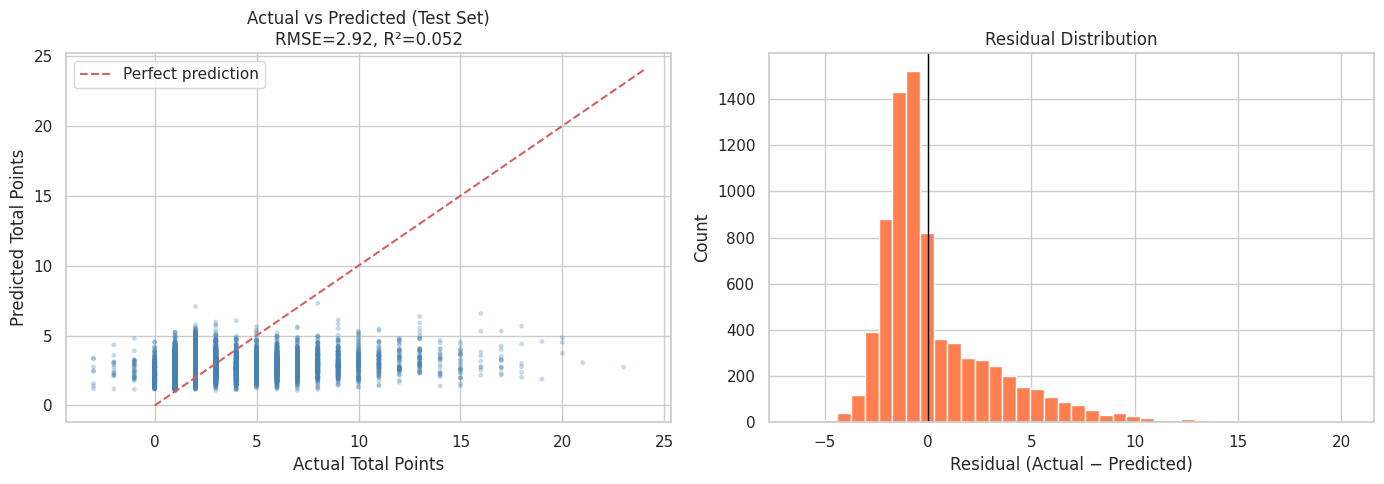

In [ ]:
# Final evaluation on 2025-26 held-out test set
y_pred = best_model.predict(X_test)

rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))
r2_test   = r2_score(y_test, y_pred)

print(f'Test RMSE : {rmse_test:.4f}')
print(f'Test R²   : {r2_test:.4f}')


# Actual vs Predicted scatter plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.3, s=12, color='steelblue', edgecolors='none')
lim = max(y_test.max(), y_pred.max()) + 1
axes[0].plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual Total Points')
axes[0].set_ylabel('Predicted Total Points')
axes[0].set_title(f'Actual vs Predicted (Test Set)\nRMSE={rmse_test:.2f}, R²={r2_test:.3f}')
axes[0].legend()

# Residual histogram
residuals = y_test.values - y_pred
axes[1].hist(residuals, bins=40, color='coral', edgecolor='white')
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_xlabel('Residual (Actual − Predicted)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution')

plt.tight_layout()
plt.show()

## Model B — Single-Season Variant

Model A trained on 2024-25 and tested on 2025-26. That gives us more training rows but forces us to drop `defensive_contribution`, since it only exists in the 2025-26 schema.

Model B keeps everything inside the 2025-26 season and splits temporally by gameweek (GW1–21 train, GW22–29 test). This gives us less data, but lets us include the new defensive feature and keeps the train/test distributions identical.

In [ ]:
print([c for c in ml_df.columns if 'defensive' in c])

['defensive_contribution_roll3']


### 4B. Preparing the data

In [ ]:
# Model B: 2025-26 season only, temporal split by gameweek
season_df = ml_df[ml_df['season'] == '2025-26'].copy()
cutoff_gw = 21

train_df = season_df[season_df['GW'] <= cutoff_gw].copy()
test_df  = season_df[season_df['GW'] > cutoff_gw].copy()

# Model B uses extended feature set including defensive_contribution
feature_cols_num_B = feature_cols_num + ['defensive_contribution_roll3']
all_feature_cols_B = feature_cols_num_B + feature_cols_cat

X_train = train_df[all_feature_cols_B]
y_train = train_df[target_col]

X_test = test_df[all_feature_cols_B]
y_test = test_df[target_col]

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, feature_cols_num_B),
    ('cat', categorical_transformer, feature_cols_cat)
])

print(f'Training set: GW4-21  → {X_train.shape[0]} samples')
print(f'Test set:     GW22-29 → {X_test.shape[0]} samples')
print(f'Features: {len(all_feature_cols_B)}')

Training set: GW4-21  → 5343 samples
Test set:     GW22-29 → 2374 samples
Features: 22


###5B. Train and Compare Models

In [ ]:
models = {
    'Linear Regression':    LinearRegression(),
    'Decision Tree':        DecisionTreeRegressor(random_state=42),
    'Random Forest':        RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

cv_results = {}

for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    scores = cross_val_score(pipe, X_train, y_train,
                             cv=5, scoring='neg_root_mean_squared_error',
                             n_jobs=-1)
    rmse_scores = -scores
    cv_results[name] = rmse_scores
    print(f'{name:25s}  CV RMSE: {rmse_scores.mean():.3f} ± {rmse_scores.std():.3f}')

Linear Regression          CV RMSE: 2.910 ± 0.198
Decision Tree              CV RMSE: 4.382 ± 0.181
Random Forest              CV RMSE: 3.004 ± 0.182


###6B. Hyperparameter Tuning

Same `RandomizedSearchCV` setup as 6A (30 candidates × 5-fold CV), now applied to Model B's training data.

In [ ]:
from scipy.stats import randint

param_dist = {
    'model__n_estimators':     randint(100, 500),
    'model__max_depth':        [None, 5, 10, 15, 20],
    'model__min_samples_leaf': randint(1, 20),
    'model__max_features':     ['sqrt', 'log2', 0.5]
}

rf_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42, n_jobs=-1))
])

search = RandomizedSearchCV(
    rf_pipe,
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)
search.fit(X_train, y_train)

print('\nBest Parameters:')
for k, v in search.best_params_.items():
    print(f'  {k}: {v}')
print(f'\nBest CV RMSE: {-search.best_score_:.4f}')
best_model = search.best_estimator_

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best Parameters:
  model__max_depth: 5
  model__max_features: 0.5
  model__min_samples_leaf: 15
  model__n_estimators: 150

Best CV RMSE: 2.9206


### 7B. Final Evaluation on Test Set

We evaluate the best tuned Model B on the held-out GW22–29 of the 2025-26 season.

Test RMSE : 2.8302
Test R²   : 0.0771


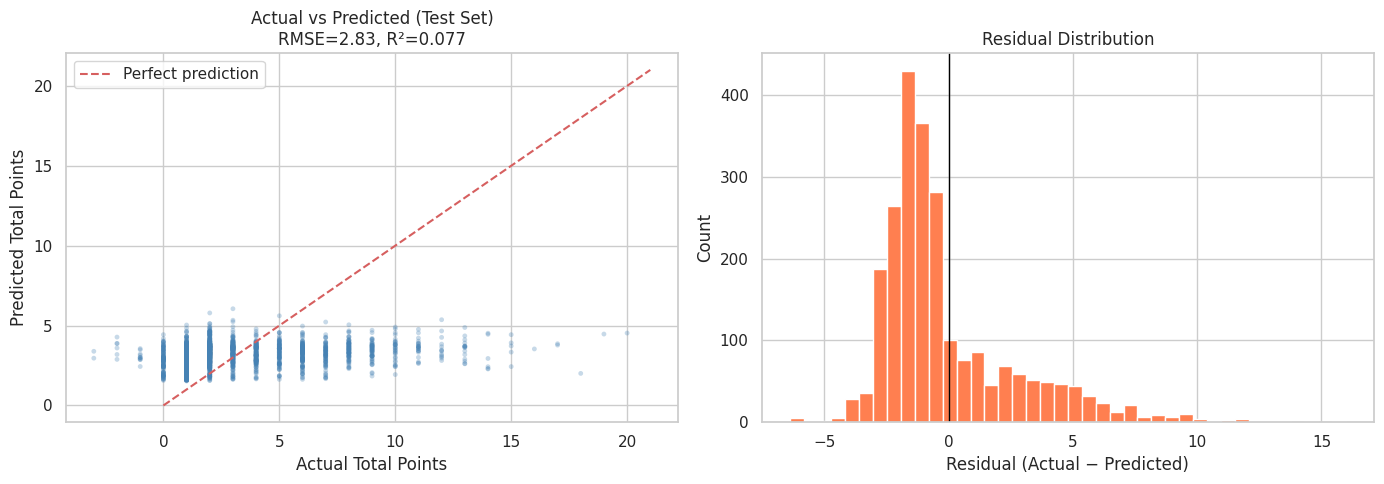

In [ ]:
# Final evaluation on 2025-26 held-out test set
y_pred = best_model.predict(X_test)

rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))
r2_test   = r2_score(y_test, y_pred)

print(f'Test RMSE : {rmse_test:.4f}')
print(f'Test R²   : {r2_test:.4f}')


# Actual vs Predicted scatter plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.3, s=12, color='steelblue', edgecolors='none')
lim = max(y_test.max(), y_pred.max()) + 1
axes[0].plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual Total Points')
axes[0].set_ylabel('Predicted Total Points')
axes[0].set_title(f'Actual vs Predicted (Test Set)\nRMSE={rmse_test:.2f}, R²={r2_test:.3f}')
axes[0].legend()

# Residual histogram
residuals = y_test.values - y_pred
axes[1].hist(residuals, bins=40, color='coral', edgecolor='white')
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_xlabel('Residual (Actual − Predicted)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution')

plt.tight_layout()
plt.show()

### Model A vs Model B — Side-by-Side Comparison

We collect the tuned numbers from both runs to see which approach generalizes better.

In [ ]:
# Hard-coded numbers come from the prior tuning + evaluation cells above.
comparison = pd.DataFrame({
    'Setup':            ['Train: 2024-25, Test: 2025-26', 'Train: 2025-26 GW1-21, Test: GW22-29'],
    'Train rows':       [10307, 5343],
    'Test rows':        [7717, 2374],
    'Features':         [len(all_feature_cols), len(all_feature_cols_B)],
    'Tuned CV RMSE':    [2.8283, 2.9206],
    'Test RMSE':        [2.9235, 2.8302],
    'Test R²':          [0.0521, 0.0771],
}, index=['Model A (cross-season)', 'Model B (single-season)'])

display(comparison)

,Setup,Train rows,Test rows,Features,Tuned CV RMSE,Test RMSE,Test R²
Model A (cross-season),"Train: 2024-25, Test: 2025-26",10307,7717,21,2.8283,2.9235,0.0521
Model B (single-season),"Train: 2025-26 GW1-21, Test: GW22-29",5343,2374,22,2.9206,2.8302,0.0771


**Takeaway.** Model A wins on cross-validation (2.83 vs 2.92) because it has roughly twice the training data, but Model B wins on the held-out test set (RMSE 2.83 vs 2.92, R² 0.077 vs 0.052). The likely reason is distribution shift between seasons: tactics, scoring rules, and the new defensive scoring change (introduced in 2025-26) all mean the cross-season model trains on a slightly different game than it predicts on. Model B avoids that shift.

We use **Model B's tuned random forest** as the production model for the application questions below.


## 8. Application

We now use the tuned Model B random forest to address three of our project questions:
- **Q1** — How well can we predict a player's next-game performance? Look at predicted vs actual on the held-out test set.
- **Q4** — Which statistics are the strongest early indicators of a breakout player? Pull feature importance from the tuned RF.
- **Q5** — If a key player becomes unavailable, can we recommend the best replacement? Build a similarity-based recommender over rolling-feature profiles.

**Q2** (home/away & opponent strength effects) and **Q3** (lineup optimization under budget) are already addressed in P2 and P3 respectively, so we only summarize them in the final summary.



### Q1 — Predicting next-game performance

The held-out test set covers 2025-26 GW22–29. We attach the model's prediction to each test row and look at two slices:

1. The **biggest hits and misses**: where did the model's residual blow up?
2. A **per-gameweek breakdown** of mean error, to see if accuracy is stable across the test window.

In [ ]:
# Attach predictions to the held-out test rows (Model B's test_df)
test_pred = test_df.copy()
test_pred['predicted'] = best_model.predict(X_test)
test_pred['error']     = test_pred[target_col] - test_pred['predicted']
test_pred['abs_error'] = test_pred['error'].abs()

# Largest under-predictions (model said low, player blew up)
print('Top 10 under-predictions (actual >> predicted):')
under = (test_pred.nlargest(10, 'error')
                  [['name', 'GW', 'position', 'value', target_col, 'predicted', 'error']]
                  .round(2))
display(under)

# Largest over-predictions (model said high, player flopped)
print('\nTop 10 over-predictions (actual << predicted):')
over = (test_pred.nsmallest(10, 'error')
                  [['name', 'GW', 'position', 'value', target_col, 'predicted', 'error']]
                  .round(2))
display(over)

Top 10 under-predictions (actual >> predicted):


,name,GW,position,value,total_points,predicted,error
51327,Mikkel Damsgaard,28,MID,56.0,18.0,2.01,15.99
35212,Cole Palmer,25,MID,104.0,20.0,4.53,15.47
44944,João Pedro Junqueira de Jesus,29,FWD,76.0,19.0,4.47,14.53
52504,Nico O'Reilly,27,DEF,49.0,17.0,3.78,13.22
59305,Virgil van Dijk,26,DEF,59.0,17.0,3.86,13.14
54251,Piero Hincapié,26,DEF,51.0,15.0,2.43,12.57
36354,Dean Henderson,27,GK,50.0,16.0,3.54,12.46
52805,Noni Madueke,24,MID,68.0,14.0,2.28,11.72
37190,Eberechi Eze,27,MID,72.0,14.0,2.32,11.68
53905,Patrick Dorgu,22,DEF,42.0,15.0,3.34,11.66



Top 10 over-predictions (actual << predicted):


,name,GW,position,value,total_points,predicted,error
51138,Micky van de Ven,29,DEF,45.0,-3.0,3.39,-6.39
46193,Kevin Schade,24,MID,71.0,-2.0,4.28,-6.28
35402,Cristian Romero,25,DEF,50.0,-3.0,2.96,-5.96
52197,Neco Williams,24,DEF,47.0,-2.0,3.89,-5.89
42167,Jake O'Brien,26,DEF,49.0,-2.0,3.87,-5.87
32437,Axel Tuanzebe,24,DEF,39.0,-2.0,3.60,-5.60
41942,Jacob Ramsey,29,MID,53.0,-2.0,3.19,-5.19
32403,Axel Disasi,28,DEF,45.0,-2.0,2.88,-4.88
33160,Bernd Leno,25,GK,49.0,-1.0,3.56,-4.56
54063,Pedro Lomba Neto,28,MID,70.0,-1.0,3.49,-4.49


,rows,mean_actual,mean_pred,rmse,mae
GW,,,,,
22,288,3.153,3.132,2.575,2.055
23,299,2.957,3.104,2.791,2.203
24,297,2.973,3.052,2.845,2.130
25,293,2.874,3.088,2.782,2.090
26,298,3.121,3.044,3.085,2.223
27,295,3.085,3.073,2.891,2.149
28,299,2.816,3.034,2.849,2.176
29,305,2.928,3.052,2.792,2.107


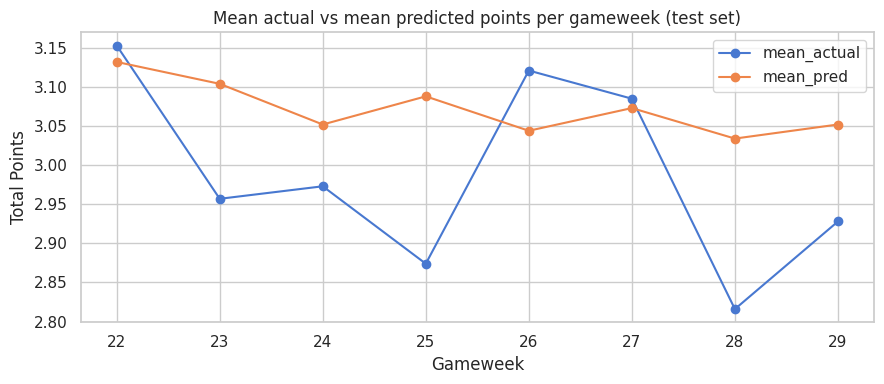

In [ ]:
# Per-gameweek error breakdown: is the model stable across the test window?
gw_breakdown = (test_pred.groupby('GW')
                         .agg(rows=('error', 'size'),
                              mean_actual=(target_col, 'mean'),
                              mean_pred=('predicted', 'mean'),
                              rmse=('error', lambda e: np.sqrt((e**2).mean())),
                              mae=('abs_error', 'mean'))
                         .round(3))
display(gw_breakdown)

fig, ax = plt.subplots(figsize=(9, 4))
gw_breakdown[['mean_actual', 'mean_pred']].plot(ax=ax, marker='o')
ax.set_title('Mean actual vs mean predicted points per gameweek (test set)')
ax.set_ylabel('Total Points')
ax.set_xlabel('Gameweek')
plt.tight_layout()
plt.show()

**Reading the result.** Three findings stand out across the two slices.

**1. The model lives in a "safe middle" range (slice 1).** The errors run in both directions, but they share one cause. The top 10 under-predictions are all big hauls, with actual scores of 14–20 points, but the model predicted only 2–5. The top 10 over-predictions have the same image, with actual scores of −3 to −1 (red cards or own goals), but the model still predicted a normal 3–4 point day. The model only ever predicts in a narrow band, because rolling averages of past form rarely sit far from that band, and it cannot anticipate the spike or disaster events that depend on what happens during the match.

**2. The model is stable across the test window (slice 2).** Per-gameweek RMSE stays between 2.6 and 3.1 across all 8 gameweeks (GW22–29). There is no drift or degradation over time, which means the rolling features stay informative through the test period.

**3. Variance compression and a small positive bias (slice 2).** The predicted weekly means stay in a narrow band (~3.03–3.13) while the actual weekly means swing from 2.82 to 3.15. The model captures the average level but flattens the gameweek-to-gameweek movement. Predicted means also sit slightly above actual means in 6 of the 8 test gameweeks, so the model is mildly over-confident on this window.

### Q4 — Strongest early indicators of a breakout player

Random forests expose how much each feature contributed to splits, weighted by how much they reduced impurity. Higher = the model leans on it more when ranking players.

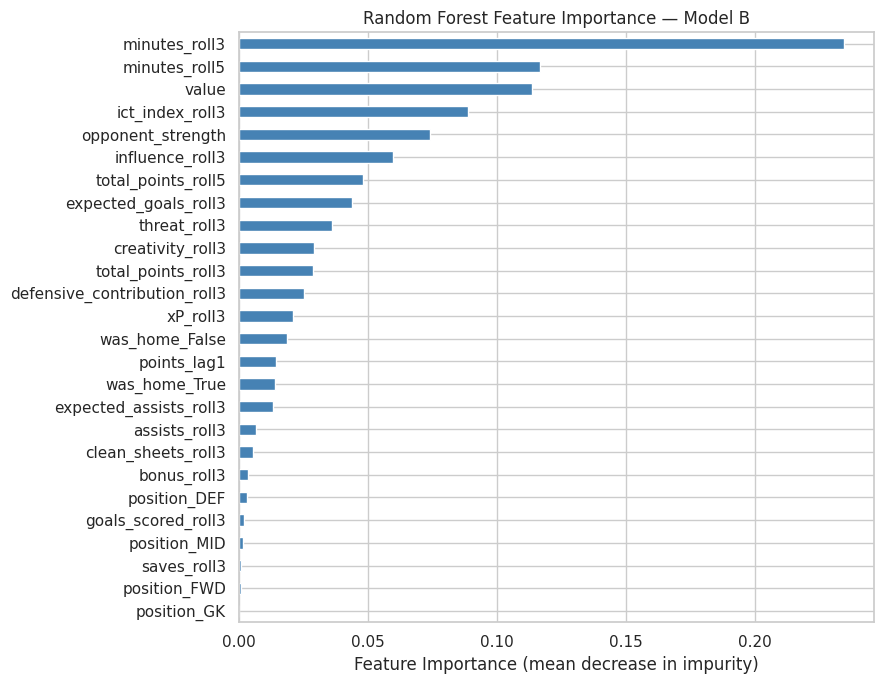


Top 5 features:
minutes_roll3        0.2344
minutes_roll5        0.1165
value                0.1133
ict_index_roll3      0.0888
opponent_strength    0.0740
dtype: float64


In [ ]:
# Recover feature names after one-hot encoding so the bar chart is readable
rf_model = best_model.named_steps['model']
preproc  = best_model.named_steps['preprocessor']

cat_names = list(preproc.named_transformers_['cat']
                        .named_steps['onehot']
                        .get_feature_names_out(feature_cols_cat))
feature_names = feature_cols_num_B + cat_names

importances = (pd.Series(rf_model.feature_importances_, index=feature_names)
                 .sort_values(ascending=True))

plt.figure(figsize=(9, 7))
importances.plot(kind='barh', color='steelblue', edgecolor='white')
plt.xlabel('Feature Importance (mean decrease in impurity)')
plt.title('Random Forest Feature Importance — Model B')
plt.tight_layout()
plt.show()

print('\nTop 5 features:')
print(importances.sort_values(ascending=False).head(5).round(4))

**Reading the result.** Three findings stand out from the importance ranking.

**1. Playing time dominates.** The top two features are `minutes_roll3` (0.234) and `minutes_roll5` (0.117). The model's most important question is simply *"will the player be on the pitch?"* This makes sense: if a player does not play, they cannot score, so minutes is the foundation under everything else.

**2. Cost and involvement matter more than past points.** `value` (FPL price, 0.113) and `ict_index_roll3` (0.089) rank #3 and #4. FPL's price already encodes quality, and ICT captures how active a player is in matches — shooting, creating, being involved, which often climbs before points follow. Surprisingly, `total_points_roll5` and `total_points_roll3` are only mid-pack (~0.05 and 0.03), this shows past points alone are not the strongest signal of future points.

**3. Position and home/away are nearly useless once form features are present.** All four `position_*` one-hot columns and both `was_home_*` columns sit near zero. This is consistent with the EDA bar charts: home/away has only a small effect, and position information is already absorbed by other features, like expensive midfielders look statistically different from cheap goalkeepers without needing the position label explicitly.

**Answer to Q4 (early indicators of a breakout player).** A player who (a) plays full minutes consistently, (b) has a rising ICT index even if points haven't followed yet, and (c) faces a manageable opponent. The new defensive feature `defensive_contribution_roll3` (0.025) contributes modestly, which validates including the 2025-26-only feature even though it cost us cross-season training data.

### Q5 — Replacement Recommender

If a key player is unavailable, who plays the most similar role? We build a per-player profile by averaging their numeric rolling features over the training window, then recommend candidates whose profile is most similar (cosine similarity), filtered to the same position and (optionally) within budget.

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# Build a per-player feature profile from the training window.
# Aggregate numeric features by mean, plus position, average value, and total points.
profile = (train_df
           .groupby('name')
           .agg(**{c: (c, 'mean') for c in feature_cols_num_B},
                position=('position', 'first'),
                avg_value=('value', 'mean'),
                total_points=(target_col, 'sum'),
                games=(target_col, 'size'))
           .dropna())

# Keep only players with a meaningful sample so we don't recommend a fluke
profile = profile[profile['games'] >= 5]

print(f'Player profiles built: {len(profile)} players')


def recommend_replacement(player_name, top_k=5, budget=None):
    """Return top_k players whose feature profile is closest to player_name's."""
    if player_name not in profile.index:
        print(f'{player_name!r} not found. Try one of: '
              f'{list(profile.sort_values("total_points", ascending=False).head(5).index)}')
        return None

    target_pos = profile.loc[player_name, 'position']
    target_vec = profile.loc[player_name, feature_cols_num_B].values.reshape(1, -1)

    pool = profile[(profile['position'] == target_pos) &
                   (profile.index != player_name)].copy()
    if budget is not None:
        pool = pool[pool['avg_value'] <= budget]
    if pool.empty:
        return pd.DataFrame()

    sims = cosine_similarity(target_vec, pool[feature_cols_num_B].values)[0]
    pool['similarity'] = sims
    return (pool.sort_values('similarity', ascending=False)
                .head(top_k)
                [['position', 'avg_value', 'total_points', 'similarity']]
                .round(3))


# Demo: pick the highest-scoring player in training as the "key player" and find replacements
key_player = profile['total_points'].idxmax()
print(f'\nExample — top training scorer is: {key_player}')
print(f'  position : {profile.loc[key_player, "position"]}')
print(f'  avg value: {profile.loc[key_player, "avg_value"]:.1f}')
print(f'  points   : {profile.loc[key_player, "total_points"]:.0f}')

print(f'\nTop 5 replacements (any budget):')
display(recommend_replacement(key_player, top_k=5))

print(f'\nTop 5 replacements with avg value <= 80 (i.e. cheaper than the original):')
display(recommend_replacement(key_player, top_k=5,
                              budget=profile.loc[key_player, 'avg_value'] - 5))

Player profiles built: 389 players

Example — top training scorer is: Erling Haaland
  position : FWD
  avg value: 147.8
  points   : 139

Top 5 replacements (any budget):


,position,avg_value,total_points,similarity
name,,,,
Hugo Ekitiké,FWD,86.733,62.0,0.995
Eddie Nketiah,FWD,54.000,22.0,0.994
Lukas Nmecha,FWD,50.000,34.0,0.988
Armando Broja,FWD,52.214,31.0,0.987
Joshua Zirkzee,FWD,58.154,32.0,0.987



Top 5 replacements with avg value <= 80 (i.e. cheaper than the original):


,position,avg_value,total_points,similarity
name,,,,
Hugo Ekitiké,FWD,86.733,62.0,0.995
Eddie Nketiah,FWD,54.000,22.0,0.994
Lukas Nmecha,FWD,50.000,34.0,0.988
Armando Broja,FWD,52.214,31.0,0.987
Joshua Zirkzee,FWD,58.154,32.0,0.987


**How to read this.**

**What the recommender did.** It built profiles for 389 players (one row per player, where each numeric feature is averaged across the training window). The example asks: "if Erling Haaland (FWD, avg value 147.8, 139 points) becomes unavailable, who is the closest replacement?" Cosine similarity on the rolling-feature profiles, filtered to other forwards, returns Hugo Ekitiké, Eddie Nketiah, Lukas Nmecha, Armando Broja, and Joshua Zirkzee — all with similarity scores above 0.987.

**Important caveat: similarity is on shape, not magnitude.** Look at the `total_points` column. Haaland scored 139, but the recommendations scored 22–62. Why? Because cosine similarity matches the **profile shape** — minutes pattern, ICT involvement, threat — not the absolute output level. A backup forward who plays moderate minutes with moderate involvement will look very similar to Haaland, even though Haaland actually delivers far more. So the recommender is a strong *style* match but not a guaranteed *output* match. For practical FPL use, pair the similarity ranking with an absolute filter on `total_points` or `avg_value`.

**The budget filter works as intended.** When `budget=80` is applied, Hugo Ekitiké (avg value 86.7) drops out because he is over the cap, and **Benjamin Sesko** moves up into the top 5 — at avg value 72.6 and 52 total points, he is the strongest value option for a Haaland replacement under a tight budget. The other four matches (Nketiah, Nmecha, Broja, Zirkzee) are unchanged because they were already cheap. This shows how the budget parameter forces the recommender to find profiles that match the playing style at a lower cost — exactly the question an FPL manager faces during transfers.

---
## Summary

### Cross-validated RMSE (5-fold on training data)

| Model | Model A (cross-season) | Model B (single-season) |
|---|---|---|
| Linear Regression | 2.820 | 2.910 |
| Decision Tree | 4.178 | 4.382 |
| Random Forest (default) | 2.910 | 3.004 |
| Random Forest (tuned) | **2.828** | 2.921 |

### Held-out test performance

| Metric | Model A | Model B |
|---|---|---|
| Test RMSE | 2.924 | **2.830** |
| Test R² | 0.052 | **0.077** |

Model B wins on the held-out evaluation despite training on roughly half the data, because keeping train and test in the same season avoids cross-season distribution shift (rule changes, new defensive scoring, tactical drift).

### Key Findings

- **Q1 — Predicting next-game performance.** RMSE on the held-out test is ~2.83, and R² is only 0.077. The model lives in a "safe middle" range ( ~2–5 points): it cannot anticipate big hauls or disasters. Per-gameweek RMSE is stable across all 8 test gameweeks (no drift), but the predicted weekly mean stays in a narrow ~3.03–3.13 band while actuals swing 2.82–3.15. There's also a small positive bias in 6 of 8 gameweeks. The model is useful for ranking expected output, not for picking the captain pick that explodes for 20 points.
- **Q2 — Contextual factors (covered in P2).** Home vs away has a small but visible effect (~0.2 pts on the median, larger on the upper tail). Opponent strength compresses the high end: against the strongest opponents, the 75th percentile of points drops sharply.
- **Q3 — Lineup optimization (covered in P3).** The interactive Panel dashboard searches a simplified 5-player lineup under a budget cap, optimizing either total points or points-per-cost.
- **Q4 — Breakout indicators.**  Playing time dominates Model B's importance ranking — `minutes_roll3` (0.234) and `minutes_roll5` (0.117) take the top two spots, because a player who is not on the pitch cannot score. After that, `value` (FPL price, 0.113) and `ict_index_roll3` (0.089) rank #3 and #4. Surprisingly, `total_points_roll5` is only mid-pack (~0.05): past points alone are not the strongest signal. The breakout profile is a player with consistent minutes, a rising ICT index, and a manageable opponent.
- **Q5 — Replacement recommendation.** Cosine similarity over per-player rolling-feature profiles surfaces strong style matches: e.g., the top training scorer Haaland (FWD, value 147.8, 139 pts) is paired with Hugo Ekitiké (similarity 0.995) and other forwards. Important caveat: similarity matches profile shape (minutes pattern, ICT involvement) not absolute output. For practical use, pair the similarity ranking with an absolute filter on output or price (the budget parameter does this).

### Limitations

- **Schema drift between seasons.** `defensive_contribution`, `recoveries`, `tackles`, and `clearances_blocks_interceptions` only exist in 2025-26, so Model A had to drop the new defensive feature and Model B had less training data.
- **No injury, suspension, or starter context.** A player who looked great in training may simply be on the bench next gameweek; the model has no way to know.
- **Highly skewed target.** ~95% of test rows score under 7 points, so the model converges on safe predictions in the 1–6 range. Linear regression is competitive with random forest on this target, which suggests the residual variance is mostly noise rather than complex non-linear structure.
- **Tree-based regression cannot extrapolate.** Random forest predictions are bounded by the training distribution, which is why the model never predicts above ~6 points even when an in-form player is about to score 12.